# Определение функционального состояния по ЭЭГ с помощью машинного обучения

Набор данных: **eeg-during-mental-arithmetic-tasks-1.0.0** (PhysioNet).

Задача: по ЭЭГ определить функциональное состояние человека:
- `background` (фоновое состояние, до задания),
- `task` (состояние умственной нагрузки во время ментальной арифметики).


### Подход
1. Загрузка EDF-записей и метаданных.
2. Эпохирование сигналов (окно 2 с, шаг 1 с).
3. Извлечение спектральных признаков: мощности ритмов и их отношения.
4. Обучение нескольких классификаторов.
5. Валидация с разбиением по субъектам (`GroupKFold`), чтобы исключить утечку.
6. Итоговая модель и предсказание по новой записи.


In [13]:
%pip install -q mne scipy scikit-learn pandas numpy matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [14]:
from pathlib import Path
import re

import matplotlib.pyplot as plt
import mne
import numpy as np
import pandas as pd
import seaborn as sns

from scipy.signal import welch
from sklearn.base import clone
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import GroupKFold, GroupShuffleSplit, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

RANDOM_STATE = 228
DATA_DIR = Path("eeg-during-mental-arithmetic-tasks-1.0.0")
INFO_CSV = DATA_DIR / "subject-info.csv"

# Параметры окна
EPOCH_SEC = 2.0
STEP_SEC = 1.0

# Частотные диапазоны (Гц)
BANDS = {
    "delta": (1, 4),
    "theta": (4, 8),
    "alpha": (8, 13),
    "beta": (13, 30),
    "gamma": (30, 40),
}

In [15]:
subject_info = pd.read_csv(INFO_CSV)
subject_info["group"] = subject_info["Count quality"].map({0: "B", 1: "G"})
print(f"Subjects in metadata: {len(subject_info)}")
subject_info.head()

Subjects in metadata: 36


,Subject,Age,Gender,Recording year,Number of subtractions,Count quality,group
0,Subject00,21,F,2011,9.70,0,B
1,Subject01,18,F,2011,29.35,1,G
2,Subject02,19,F,2012,12.88,1,G
3,Subject03,17,F,2010,31.00,1,G
4,Subject04,17,F,2010,8.60,0,B


In [16]:
# Формируем индекс EDF-файлов
edf_rows = []
pat = re.compile(r"(Subject\d+)_(\d)\.edf$")

for p in sorted(DATA_DIR.glob("Subject*_*.edf")):
    m = pat.search(p.name)
    if not m:
        continue
    subject, rec = m.group(1), m.group(2)
    condition = "background" if rec == "1" else "task"
    state_label = 0 if condition == "background" else 1
    edf_rows.append(
        {
            "subject": subject,
            "record": rec,
            "condition": condition,
            "state_label": state_label,
            "path": p,
        }
    )

edf_index = (
    pd.DataFrame(edf_rows).sort_values(["subject", "record"]).reset_index(drop=True)
)
print(f"EDF files indexed: {len(edf_index)}")
edf_index.head(8)

EDF files indexed: 72


,subject,record,condition,state_label,path
0,Subject00,1,background,0,eeg-during-mental-arithmetic-tasks-1.0.0/Subje...
1,Subject00,2,task,1,eeg-during-mental-arithmetic-tasks-1.0.0/Subje...
2,Subject01,1,background,0,eeg-during-mental-arithmetic-tasks-1.0.0/Subje...
3,Subject01,2,task,1,eeg-during-mental-arithmetic-tasks-1.0.0/Subje...
4,Subject02,1,background,0,eeg-during-mental-arithmetic-tasks-1.0.0/Subje...
5,Subject02,2,task,1,eeg-during-mental-arithmetic-tasks-1.0.0/Subje...
6,Subject03,1,background,0,eeg-during-mental-arithmetic-tasks-1.0.0/Subje...
7,Subject03,2,task,1,eeg-during-mental-arithmetic-tasks-1.0.0/Subje...


In [17]:
def load_eeg(
    path: Path, l_freq: float = 1.0, h_freq: float = 40.0
) -> tuple[np.ndarray, float]:
    raw = mne.io.read_raw_edf(path, preload=True, verbose=False)
    raw.pick("eeg")
    raw.set_eeg_reference("average", verbose=False)
    raw.filter(l_freq=l_freq, h_freq=h_freq, fir_design="firwin", verbose=False)
    data = raw.get_data()  # (n_channels, n_samples)
    sfreq = float(raw.info["sfreq"])
    return data, sfreq


def split_into_epochs(
    data: np.ndarray,
    sfreq: float,
    epoch_sec: float = EPOCH_SEC,
    step_sec: float = STEP_SEC,
):
    win = int(round(epoch_sec * sfreq))
    step = int(round(step_sec * sfreq))
    n_samples = data.shape[1]

    for start in range(0, n_samples - win + 1, step):
        stop = start + win
        yield data[:, start:stop], start / sfreq


def epoch_features(
    epoch_data: np.ndarray, sfreq: float, bands: dict[str, tuple[float, float]]
) -> dict[str, float]:
    freqs, psd = welch(
        epoch_data, fs=sfreq, nperseg=min(256, epoch_data.shape[1]), axis=1
    )
    psd_mean = psd.mean(axis=0)

    eps = 1e-12
    powers = {}
    for band, (fmin, fmax) in bands.items():
        idx = (freqs >= fmin) & (freqs < fmax)
        powers[band] = float(psd_mean[idx].sum())

    total_power = sum(powers.values()) + eps

    feats = {f"pow_{k}": v for k, v in powers.items()}
    feats.update({f"rel_{k}": v / total_power for k, v in powers.items()})

    feats["ratio_theta_alpha"] = powers["theta"] / (powers["alpha"] + eps)
    feats["ratio_beta_alpha"] = powers["beta"] / (powers["alpha"] + eps)
    feats["ratio_delta_alpha"] = powers["delta"] / (powers["alpha"] + eps)
    feats["ratio_alpha_beta"] = powers["alpha"] / (powers["beta"] + eps)
    feats["ratio_theta_beta"] = powers["theta"] / (powers["beta"] + eps)
    return feats

In [18]:
# Строим таблицу признаков (эпохи как объекты)
rows = []

for rec in edf_index.itertuples(index=False):
    data, sfreq = load_eeg(rec.path)

    for epoch_idx, (ep, t_start) in enumerate(split_into_epochs(data, sfreq)):
        feats = epoch_features(ep, sfreq, BANDS)
        feats.update(
            {
                "subject": rec.subject,
                "condition": rec.condition,
                "state_label": rec.state_label,
                "record": rec.record,
                "time_start_s": t_start,
                "epoch_idx": epoch_idx,
            }
        )
        rows.append(feats)

features_df = pd.DataFrame(rows)
features_df = features_df.merge(
    subject_info[["Subject", "Count quality", "group", "Number of subtractions"]],
    left_on="subject",
    right_on="Subject",
    how="left",
)

print("Feature table shape:", features_df.shape)
features_df.head()

Feature table shape: (8604, 25)


,pow_delta,pow_theta,pow_alpha,pow_beta,pow_gamma,rel_delta,rel_theta,rel_alpha,rel_beta,rel_gamma,...,subject,condition,state_label,record,time_start_s,epoch_idx,Subject,Count quality,group,Number of subtractions
0,1.597135e-10,9.156587e-11,6.908029e-11,6.625138e-11,1.584438e-12,0.410368,0.235270,0.177495,0.170226,0.004071,...,Subject00,background,0,1,0.0,0,Subject00,0,B,9.7
1,1.508725e-10,1.032100e-10,7.906952e-11,7.486112e-11,1.504413e-12,0.367518,0.251414,0.192609,0.182358,0.003665,...,Subject00,background,0,1,1.0,1,Subject00,0,B,9.7
2,1.406964e-10,9.737044e-11,8.365743e-11,7.580981e-11,1.354067e-12,0.351839,0.243494,0.209202,0.189578,0.003386,...,Subject00,background,0,1,2.0,2,Subject00,0,B,9.7
3,1.387810e-10,6.008277e-11,5.785943e-11,5.489440e-11,1.141878e-12,0.442316,0.191493,0.184407,0.174957,0.003639,...,Subject00,background,0,1,3.0,3,Subject00,0,B,9.7
4,1.357891e-10,5.619925e-11,5.556008e-11,5.209554e-11,1.114085e-12,0.449993,0.186239,0.184121,0.172640,0.003692,...,Subject00,background,0,1,4.0,4,Subject00,0,B,9.7


condition
background    6408
task          2196
Name: count, dtype: int64


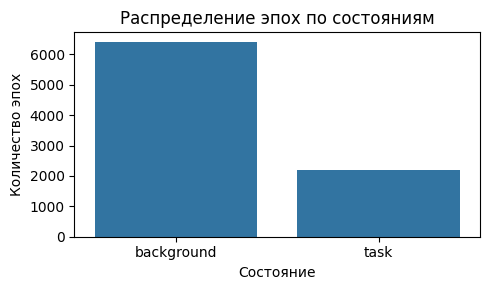

In [19]:
# Проверка баланса классов
class_counts = features_df["condition"].value_counts()
print(class_counts)

plt.figure(figsize=(5, 3))
sns.barplot(x=class_counts.index, y=class_counts.values)
plt.title("Распределение эпох по состояниям")
plt.xlabel("Состояние")
plt.ylabel("Количество эпох")
plt.tight_layout()

In [20]:
# Формируем X, y, groups
meta_cols = {
    "subject",
    "condition",
    "state_label",
    "record",
    "time_start_s",
    "epoch_idx",
    "Subject",
    "Count quality",
    "group",
    "Number of subtractions",
}
feature_cols = [c for c in features_df.columns if c not in meta_cols]

X = features_df[feature_cols].to_numpy()
y = features_df["state_label"].to_numpy()
groups = features_df["subject"].to_numpy()

print("n_features:", len(feature_cols))
print("n_samples:", len(X))

n_features: 15
n_samples: 8604


In [21]:
# Модели
models = {
    "LogReg": Pipeline(
        [
            ("scaler", StandardScaler()),
            (
                "clf",
                LogisticRegression(
                    max_iter=1500, class_weight="balanced", random_state=RANDOM_STATE
                ),
            ),
        ]
    ),
    "SVM-RBF": Pipeline(
        [
            ("scaler", StandardScaler()),
            (
                "clf",
                SVC(
                    kernel="rbf",
                    C=2.0,
                    gamma="scale",
                    probability=True,
                    class_weight="balanced",
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    ),
    "RandomForest": RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_leaf=2,
        class_weight="balanced_subsample",
        n_jobs=-1,
        random_state=RANDOM_STATE,
    ),
}

cv = GroupKFold(n_splits=5)
scoring = ["accuracy", "f1", "roc_auc"]

cv_rows = []
for name, model in models.items():
    scores = cross_validate(
        model,
        X,
        y,
        groups=groups,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        error_score="raise",
    )
    cv_rows.append(
        {
            "model": name,
            "accuracy_mean": scores["test_accuracy"].mean(),
            "accuracy_std": scores["test_accuracy"].std(),
            "f1_mean": scores["test_f1"].mean(),
            "f1_std": scores["test_f1"].std(),
            "roc_auc_mean": scores["test_roc_auc"].mean(),
            "roc_auc_std": scores["test_roc_auc"].std(),
        }
    )

cv_results = (
    pd.DataFrame(cv_rows)
    .sort_values("roc_auc_mean", ascending=False)
    .reset_index(drop=True)
)
cv_results

,model,accuracy_mean,accuracy_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std
0,LogReg,0.564869,0.140364,0.400609,0.088257,0.610643,0.085634
1,SVM-RBF,0.565364,0.080622,0.352536,0.025989,0.546496,0.054900
2,RandomForest,0.625966,0.089237,0.251610,0.033305,0.512313,0.062466


Best model: LogReg
Test subjects: ['Subject02', 'Subject04', 'Subject06', 'Subject11', 'Subject14', 'Subject26', 'Subject27', 'Subject35']
ROC-AUC: 0.6994
              precision    recall  f1-score   support

  background       0.88      0.29      0.44      1436
        task       0.30      0.89      0.45       488

    accuracy                           0.44      1924
   macro avg       0.59      0.59      0.44      1924
weighted avg       0.73      0.44      0.44      1924



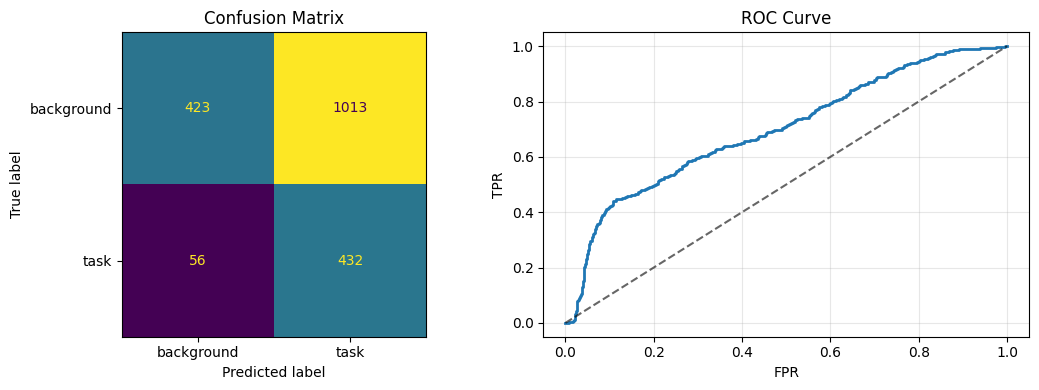

In [22]:
# Финальная оценка на отдельном group-aware тесте
best_name = cv_results.iloc[0]["model"]
best_model = clone(models[best_name])
print("Best model:", best_name)

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]
subj_test = pd.Series(groups[test_idx]).unique()

best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

if hasattr(best_model, "predict_proba"):
    y_score = best_model.predict_proba(X_test)[:, 1]
else:
    y_score = best_model.decision_function(X_test)

print("Test subjects:", sorted(subj_test.tolist()))
print("ROC-AUC:", round(roc_auc_score(y_test, y_score), 4))
print(classification_report(y_test, y_pred, target_names=["background", "task"]))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["background", "task"],
    colorbar=False,
    ax=axes[0],
)
axes[0].set_title("Confusion Matrix")

fpr, tpr, _ = roc_curve(y_test, y_score)
axes[1].plot(fpr, tpr, linewidth=2)
axes[1].plot([0, 1], [0, 1], "k--", alpha=0.6)
axes[1].set_xlabel("FPR")
axes[1].set_ylabel("TPR")
axes[1].set_title("ROC Curve")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()

,feature,importance
12,ratio_delta_alpha,1.045425
10,ratio_theta_alpha,0.767323
0,pow_delta,0.694545
3,pow_beta,0.640378
6,rel_theta,0.531843
2,pow_alpha,0.503901
5,rel_delta,0.409297
8,rel_beta,0.371067
13,ratio_alpha_beta,0.315864
7,rel_alpha,0.240862


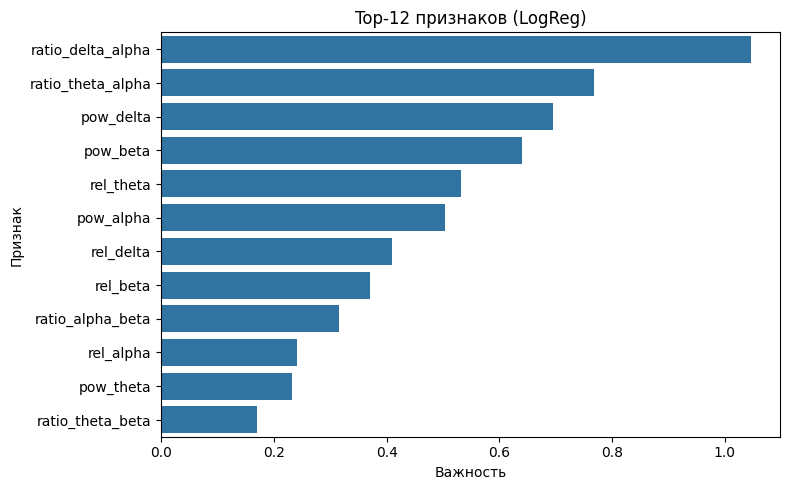

In [23]:
# Важность признаков
if isinstance(best_model, Pipeline):
    estimator = best_model.named_steps["clf"]
else:
    estimator = best_model

if hasattr(estimator, "feature_importances_"):
    importances = estimator.feature_importances_
elif hasattr(estimator, "coef_"):
    coef = estimator.coef_
    importances = np.abs(coef).ravel()
else:
    importances = np.zeros(len(feature_cols))

imp_df = pd.DataFrame({"feature": feature_cols, "importance": importances})
imp_df = imp_df.sort_values("importance", ascending=False).head(12)

plt.figure(figsize=(8, 5))
sns.barplot(data=imp_df, y="feature", x="importance", orient="h")
plt.title(f"Top-12 признаков ({best_name})")
plt.xlabel("Важность")
plt.ylabel("Признак")
plt.tight_layout()

imp_df

True state for Subject00_2.edf: task
Epoch-level accuracy on this file: 0.344


,time_start_s,proba_task,pred_state,true_state
0,0.0,0.486328,background,task
1,1.0,0.352229,background,task
2,2.0,0.373118,background,task
3,3.0,0.366614,background,task
4,4.0,0.284074,background,task


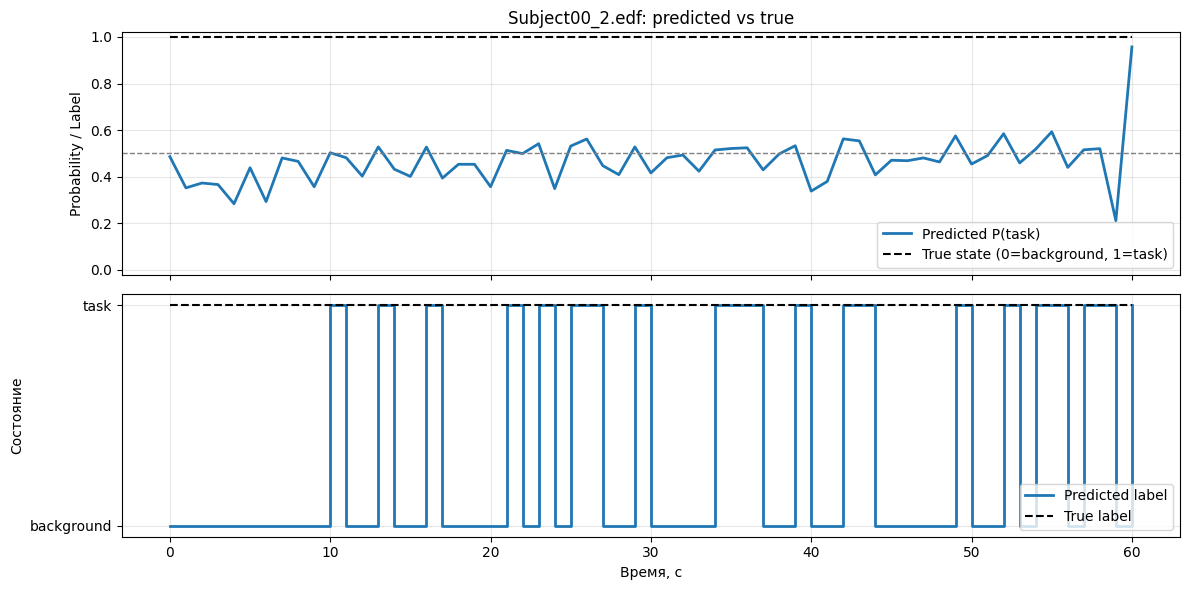

In [24]:
# Функция для прогноза функционального состояния по одному EDF-файлу
def infer_true_state_from_filename(edf_path: Path) -> tuple[int, str]:
    m = re.search(r"_(\d)\.edf$", edf_path.name)
    if m is None:
        raise ValueError(
            f"Не удалось определить true state из имени файла: {edf_path.name}"
        )
    label = 0 if m.group(1) == "1" else 1
    state = "background" if label == 0 else "task"
    return label, state


def predict_state_timeline(
    edf_path: Path, model, feature_columns: list[str]
) -> pd.DataFrame:
    data, sfreq = load_eeg(edf_path)
    rows = []
    for i, (ep, t_start) in enumerate(split_into_epochs(data, sfreq)):
        f = epoch_features(ep, sfreq, BANDS)
        f["epoch_idx"] = i
        f["time_start_s"] = t_start
        rows.append(f)

    df = pd.DataFrame(rows)
    X_file = df[feature_columns].to_numpy()

    if hasattr(model, "predict_proba"):
        proba_task = model.predict_proba(X_file)[:, 1]
    else:
        score = model.decision_function(X_file)
        proba_task = 1 / (1 + np.exp(-score))

    pred = (proba_task >= 0.5).astype(int)
    true_label, true_state = infer_true_state_from_filename(edf_path)

    df["proba_task"] = proba_task
    df["pred_label"] = pred
    df["pred_state"] = np.where(pred == 1, "task", "background")
    df["true_label"] = true_label
    df["true_state"] = true_state
    return df


sample_file = DATA_DIR / "Subject00_2.edf"
timeline_df = predict_state_timeline(sample_file, best_model, feature_cols)

file_acc = (timeline_df["pred_label"] == timeline_df["true_label"]).mean()
print(f"True state for {sample_file.name}: {timeline_df['true_state'].iloc[0]}")
print(f"Epoch-level accuracy on this file: {file_acc:.3f}")

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

# График вероятности + реальный класс
axes[0].plot(
    timeline_df["time_start_s"],
    timeline_df["proba_task"],
    linewidth=2,
    label="Predicted P(task)",
)
axes[0].step(
    timeline_df["time_start_s"],
    timeline_df["true_label"],
    where="post",
    linestyle="--",
    color="black",
    linewidth=1.5,
    label="True state (0=background, 1=task)",
)
axes[0].axhline(0.5, linestyle="--", color="grey", linewidth=1)
axes[0].set_ylim(-0.02, 1.02)
axes[0].set_ylabel("Probability / Label")
axes[0].set_title(f"{sample_file.name}: predicted vs true")
axes[0].legend(loc="lower right")
axes[0].grid(True, alpha=0.3)

# График меток классов
axes[1].step(
    timeline_df["time_start_s"],
    timeline_df["pred_label"],
    where="post",
    linewidth=2,
    label="Predicted label",
)
axes[1].step(
    timeline_df["time_start_s"],
    timeline_df["true_label"],
    where="post",
    linestyle="--",
    color="black",
    linewidth=1.5,
    label="True label",
)
axes[1].set_yticks([0, 1])
axes[1].set_yticklabels(["background", "task"])
axes[1].set_xlabel("Время, с")
axes[1].set_ylabel("Состояние")
axes[1].legend(loc="lower right")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()

timeline_df[["time_start_s", "proba_task", "pred_state", "true_state"]].head()